In [1]:
! pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


## Load universal sentence encoder

In [2]:
from absl import logging
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import os
import pandas as pd
import re
import seaborn as sns


In [3]:
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(module_url)
print("module %s loaded" % module_url)
def embed(input):
  return model(input)

module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


In [6]:
word = "Elephant"
sentence = "The elephant is the largest land animal on Earth."
paragraph = "The elephant is the largest land animal on Earth. It has a trunk, tusks, and large ears. Elephants are known for their intelligence and strong social bonds."
messages = [word, sentence, paragraph]

#reduce logging output
logging.set_verbosity(logging.ERROR)

message_embeddings = embed(messages)

for i, message_embedding in enumerate(np.array(message_embeddings)):
  print("Message: {}".format(messages[i]))
  print("Embedding size: {}".format(len(message_embedding)))
  message_embedding_snipet = ", ".join((str(x) for x in message_embedding[:3]))
  print("Embedding: [{}, ...]\n".format(message_embedding_snipet))

Message: Elephant
Embedding size: 512
Embedding: [0.008344487, 0.0004808583, 0.06595248, ...]

Message: The elephant is the largest land animal on Earth.
Embedding size: 512
Embedding: [-0.039626, -0.05823745, 0.047235407, ...]

Message: The elephant is the largest land animal on Earth. It has a trunk, tusks, and large ears. Elephants are known for their intelligence and strong social bonds.
Embedding size: 512
Embedding: [-0.038592055, 0.021607533, 0.03558724, ...]



## Semantic textual similarity

In [17]:
def plot_similarity(labels, features, rotation):
  corr = np.inner(features, features)
  sns.set(font_scale=1.2)
  g = sns.heatmap(
      corr,
      xticklabels=labels,
      yticklabels=labels,
      vmin=0,
      vmax=1,
      cmap="YlOrRd")
  g.set_xticklabels(labels, rotation=rotation)
  g.set_title("Semantic Similarity")
  plt.show()


def run_and_plot(messages):
  message_embeddings = embed(messages)
  plot_similarity(messages, message_embeddings, 90)


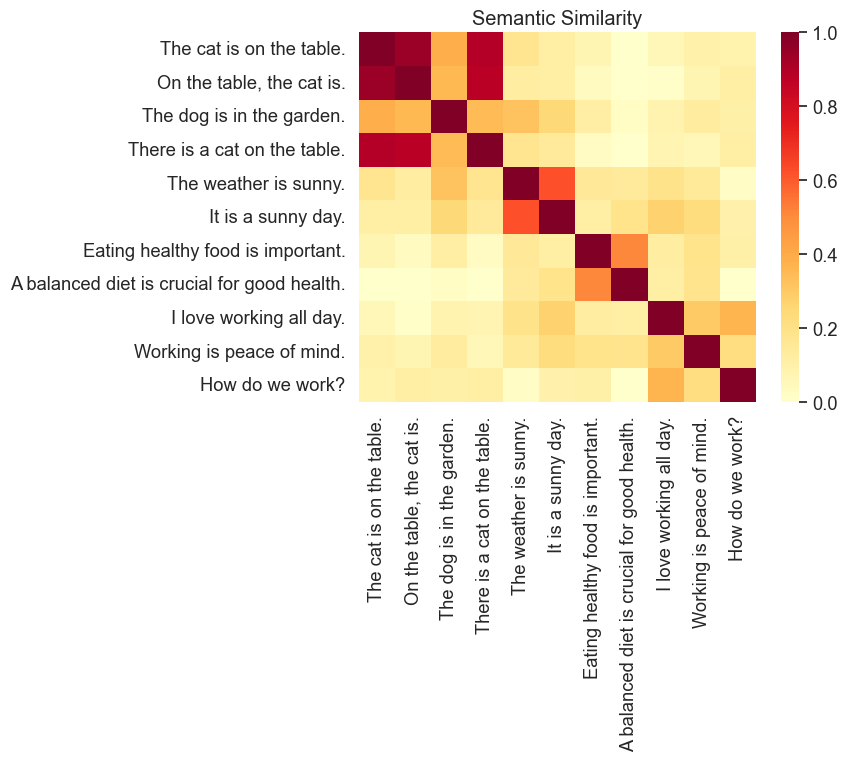

In [20]:
messages = [
    #pet
    "The cat is on the table.",
    "On the table, the cat is.",
    "The dog is in the garden.",
    "There is a cat on the table.",
    #Weather
    "The weather is sunny.",
    "It is a sunny day.",

    #food and health
    "Eating healthy food is important.",
    "A balanced diet is crucial for good health.",

    #work
    "I love working all day.",
    "Working is peace of mind.",
    "How do we work?"
]
run_and_plot(messages)